# **Part 1: Retail Analytics Report – HighlandGear**
**1. Data Initialization and Environment Setup**

In this section, we import the necessary libraries for data manipulation (*pandas*), network analysis (*networkx*), and visualization (*matplotlib*). We then load the primary datasets: ***transactions.csv***, which contains purchase history, and ***referrals.csv***, which maps social connections between customers.

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Load Datasets
transactions = pd.read_csv('transactions.csv')
referrals = pd.read_csv('referrals.csv')

**2. Association Rule Mining**

Identifying Product Bundling Opportunities
This section applies Market Basket Analysis to identify products that are frequently purchased together. By calculating Support, Confidence, and Lift, we can determine which product pairings are result of intentional consumer behavior rather than random chance.

*Lift* > 1 indicates a strong positive association between products.

Confidence measures the reliability of the prediction that a customer buying Product ***A*** will also buy Product ***B***.

In [ ]:
# Step 1: Data Pre-processing
trans_list = transactions['products'].str.split(', ').tolist()
total_trans = len(trans_list)

# Step 2: Calculate Item Frequencies
item_counts = Counter()
for t in trans_list:
    item_counts.update(t)

# Step 3: Calculate Pair Frequencies
pair_counts = Counter()
for t in trans_list:
    for p in combinations(sorted(set(t)), 2):
        pair_counts[p] += 1

# Step 4: Generate Metrics (Support, Confidence, and Lift)
rules_data = []
for (item_a, item_b), count in pair_counts.items():
    supp = count / total_trans
    supp_a = item_counts[item_a] / total_trans
    supp_b = item_counts[item_b] / total_trans
    lift = supp / (supp_a * supp_b)

    rules_data.append({
        'Product_A': item_a, 'Product_B': item_b,
        'Support': supp, 'Confidence': count/item_counts[item_a], 'Lift': lift
    })
    rules_data.append({
        'Product_A': item_b, 'Product_B': item_a,
        'Support': supp, 'Confidence': count/item_counts[item_b], 'Lift': lift
    })

# Step 5: Sort and Present Results
rules_df = pd.DataFrame(rules_data).sort_values('Lift', ascending=False).head(10)
rules_df.reset_index(drop=True, inplace=True)
rules_df.index += 1
rules_df.index.name = 'Rank'

print("--- TOP 10 ASSOCIATION RULES BY LIFT ---")
print(rules_df[['Product_A', 'Product_B', 'Support', 'Confidence', 'Lift']])

--- TOP 10 ASSOCIATION RULES BY LIFT ---
           Product_A       Product_B   Support  Confidence      Lift
Rank                                                                
1            Dry Bag   Camping Stove  0.068744    0.553050  4.745125
2      Camping Stove         Dry Bag  0.068744    0.589816  4.745125
3         Base Layer      Beanie Hat  0.062974    0.514825  4.355547
4         Beanie Hat      Base Layer  0.062974    0.532775  4.355547
5     Trekking Poles    Hiking Socks  0.063304    0.526749  4.155084
6       Hiking Socks  Trekking Poles  0.063304    0.499350  4.155084
7       Sleeping Bag            Tent  0.124959    0.706431  3.956794
8               Tent    Sleeping Bag  0.124959    0.699908  3.956794
9       Sleeping Bag     Camping Mat  0.066436    0.375582  3.125217
10       Camping Mat    Sleeping Bag  0.066436    0.552812  3.125217


**3. Social Network Analysis (SNA)**

Influencer Identification and Network Structure
We model the referral data as a Directed Graph to understand how information and brand advocacy spread. This analysis identifies "*Power Referrers*" using Degree Centrality and evaluates the overall health of the community using Density and Clustering Coefficients.

Density reveals how interconnected the entire customer base is.

Clustering indicates the presence of "*echo chambers*" or tight-knit referral circles.

In [ ]:
# Step 1: Build the Graph
G = nx.from_pandas_edgelist(referrals, 'referrer_id', 'referred_id', create_using=nx.DiGraph())

# Step 2: Calculate Centrality
deg_cent = nx.degree_centrality(G)
top_5_inf = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
other_nodes = [n for n in G.nodes() if n not in top_5_inf]

# Step 3: Network Health Statistics
density = nx.density(G)
avg_clustering = nx.average_clustering(G.to_undirected())

print("\n--- NETWORK STATISTICS ---")
print(f"Network Density: {density:.6f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

print("\n--- TOP 5 INFLUENCERS (DEGREE CENTRALITY) ---")
for i, (cid, score) in enumerate(top_5_inf, 1):
    print(f"{i}. Customer ID: {cid} | Centrality Score: {score:.4f}")


--- NETWORK STATISTICS ---
Network Density: 0.000758
Average Clustering Coefficient: 0.0000

--- TOP 5 INFLUENCERS (DEGREE CENTRALITY) ---
1. Customer ID: C00020 | Centrality Score: 0.0215
2. Customer ID: C00152 | Centrality Score: 0.0215
3. Customer ID: C00036 | Centrality Score: 0.0215
4. Customer ID: C00109 | Centrality Score: 0.0197
5. Customer ID: C00102 | Centrality Score: 0.0197


**4. Visual Analysis**

**Graph 1: Referral Network Map**

The following visualization displays the structure of HighlandGear's referral program. The **red** nodes highlight the top 5 influencers who act as the primary engines for customer acquisition. The **black** nodes represent the general customer base, illustrating a fragmented network with multiple "silos."

*"silos" refers to fragmented clusters of customers who are disconnected from the rest of the network*

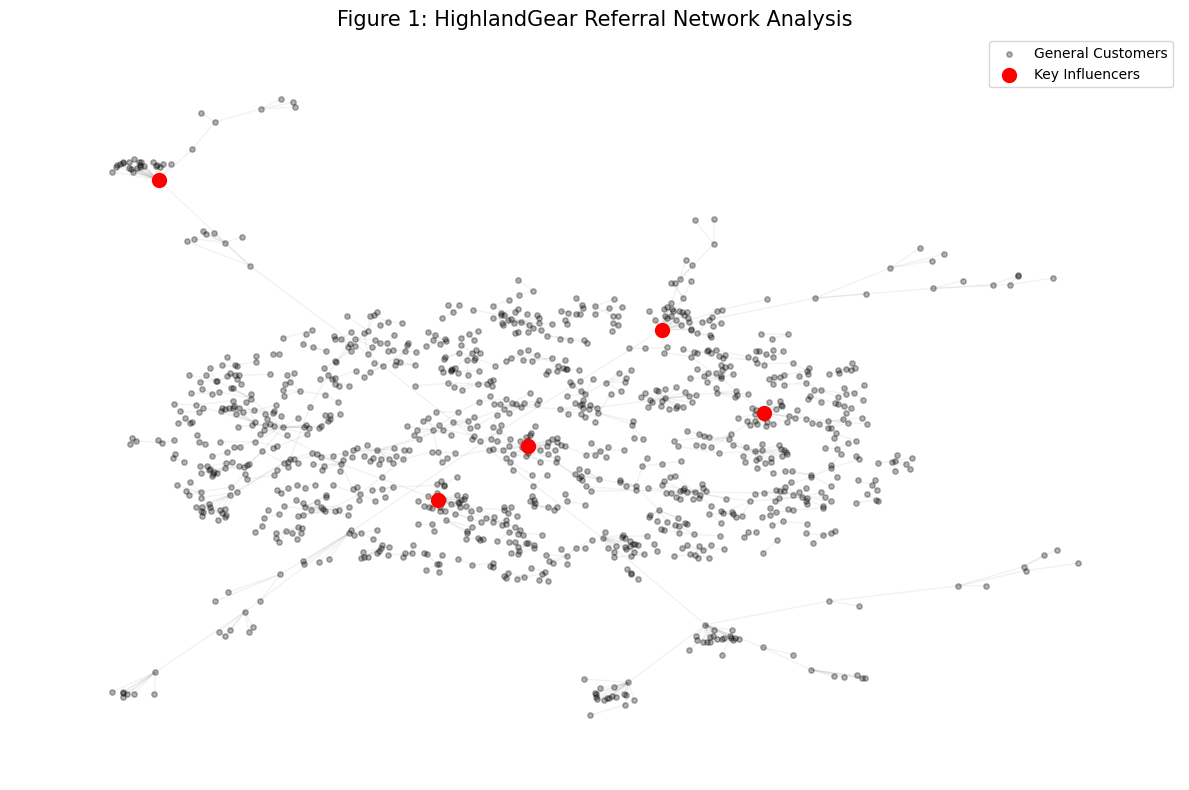

In [ ]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.15, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=15, alpha=0.3, node_color='black', label='General Customers')
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray', arrows=False)

influencer_nodes = [n for n, s in top_5_inf]
nx.draw_networkx_nodes(G, pos, nodelist=influencer_nodes, node_size=100, node_color='red', label='Key Influencers')

plt.title("Figure 1: HighlandGear Referral Network Analysis", fontsize=15)
plt.legend(scatterpoints=1)
plt.axis('off')
plt.tight_layout()
plt.show()

**Graph 2: Product Association Map**

This network map visualizes the results of our association rule mining. Products are represented as nodes, and edges represent a *Lift* > 2.5. This map helps stakeholders identify at a glance which technical gear should be bundled together to maximize revenue.

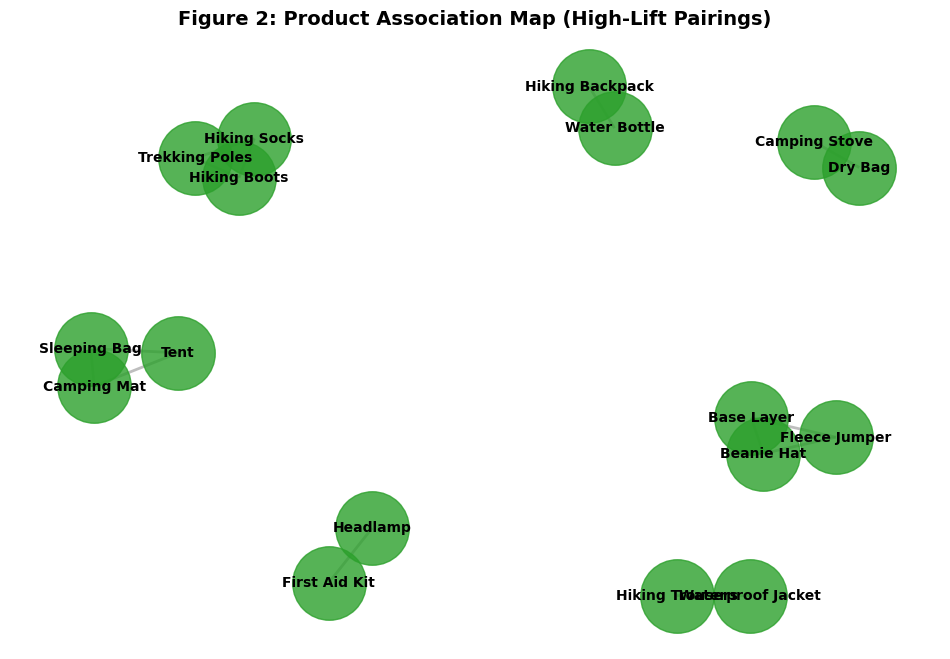

In [ ]:
# Filter associations for the graph
assoc_edges = []
for (a, b), count in pair_counts.items():
    supp = count / total_trans
    supp_a = item_counts[a] / total_trans
    supp_b = item_counts[b] / total_trans
    lift = supp / (supp_a * supp_b)
    if lift > 2.5:
        assoc_edges.append((a, b, lift))

P = nx.Graph()
for u, v, w in assoc_edges:
    P.add_edge(u, v, weight=w)

plt.figure(figsize=(12, 8))
pos_prod = nx.spring_layout(P, k=0.6, seed=42)
nx.draw_networkx_nodes(P, pos_prod, node_size=2800, node_color='#2ca02c', alpha=0.8)
nx.draw_networkx_edges(P, pos_prod, width=2, edge_color='#7f7f7f', alpha=0.5)
nx.draw_networkx_labels(P, pos_prod, font_size=10, font_weight='bold', font_color='black')

plt.title("Figure 2: Product Association Map (High-Lift Pairings)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**Graph 3: Distribution of Influence**

Finally, we analyze the distribution of referrals using a log-scale histogram. This graph provides empirical evidence of the "*Power Law*" (or **Pareto Principle**) within HighlandGear's community: a small percentage of customers are responsible for the vast majority of brand referrals.

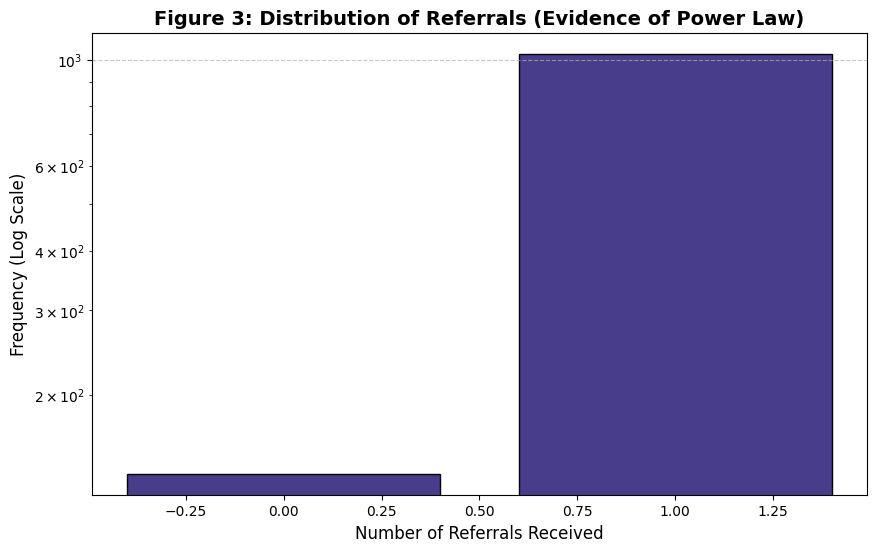

In [ ]:
in_degrees = [G.in_degree(n) for n in G.nodes()]
deg_counts = pd.Series(in_degrees).value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(deg_counts.index, deg_counts.values, color='#483d8b', edgecolor='black')
plt.xlabel("Number of Referrals Received", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)
plt.title("Figure 3: Distribution of Referrals (Evidence of Power Law)", fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#**Part 2 : Web Analytics Report: HaggisBus**
**1. Data Initialization and Environment Setup**

In this stage, we prepare the environment by importing essential libraries: *pandas* for data manipulation, *matplotlib* and *seaborn* for high-quality visualizations, and numpy for mathematical operations. Unlike standard datasets, clickstream files often contain uneven row lengths (where some users visit more pages than others). To ensure data integrity, we utilize a line-by-line reading method rather than a standard read_csv call, which would fail due to the varying column counts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data line-by-line to handle varying journey lengths
data = []
with open('visitor_data_clickstream.csv', 'r') as f:
    for line in f:
        data.append(line.strip().split(','))

# Convert to DataFrame and label metadata
df = pd.DataFrame(data)
df = df.rename(columns={0: 'Source', 1: 'Platform'})
page_cols = df.columns[2:] # Identify columns containing page paths

print(f"Environment setup complete. Loaded {len(df)} user sessions.")

Environment setup complete. Loaded 160400 user sessions.


**2. Web Metric Analysis (Conversion & Bounce)**

This section defines the logic for identifying user success. We create a custom function to scan the "*digital trail*" of each user. A Conversion is flagged if a user reaches the purchase_success page. A Bounce is defined as a user who leaves the site after only one page (Session Depth = 1). By grouping these by Source, we calculate the ROI of marketing spend.

In [ ]:
# Helper to scan paths
def has_page(row, page):
    return page in [str(x).strip() for x in row if x]

# Calculate Depth, Conversion, and Bounce
df['Depth'] = df[page_cols].apply(lambda r: sum(1 for x in r if x and x.strip() != ''), axis=1)
df['Converted'] = df[page_cols].apply(lambda r: has_page(r, 'purchase_success'), axis=1)
df['Is_Bounce'] = df['Depth'] <= 1

# Generate Marketing ROI Table
source_table = df.groupby('Source').agg(
    Visitors=('Source', 'count'),
    Conv_Rate=('Converted', 'mean'),
    Bounce_Rate=('Is_Bounce', 'mean')
).sort_values('Conv_Rate', ascending=False)

# Format as percentages for the report
source_report = source_table.copy()
source_report['Conv_Rate'] = (source_report['Conv_Rate'] * 100).round(2).astype(str) + '%'
source_report['Bounce_Rate'] = (source_report['Bounce_Rate'] * 100).round(2).astype(str) + '%'
print(source_report)

                 Visitors Conv_Rate Bounce_Rate
Source                                         
direct              13500    31.67%       9.53%
linkedin_advert      2000     25.2%        0.0%
search              57400    15.19%      18.36%
facebook_share      51300    12.98%      15.84%
linkedin_share      21200    12.01%       20.0%
partner_advert       5000     10.9%        0.0%
facebook_advert     10000     0.93%      42.62%


**3. Funnel Analysis & Friction Points**

Funnel analysis models the customer journey as a series of sequential hurdles. By counting the unique users at each "checkpoint" (Home, Pricing, Address Entry), we identify the "Leak" in the bucket. This is the most critical part of the analysis for identifying technical bugs or payment gateway issues that cause users to abandon their carts at the final second.

In [ ]:
# Define funnel steps
funnel_steps = ['home', 'pricing', 'purchase_start', 'purchase_enter_address', 'purchase_success']
funnel_labels = ['Landing Page', 'Pricing Page', 'Booking Started', 'Address Entry', 'Success']
counts = [df[page_cols].apply(lambda r: has_page(r, s), axis=1).sum() for s in funnel_steps]

# Create Funnel Table
funnel_table = pd.DataFrame({'Step': funnel_labels, 'Users': counts})
funnel_table['Retention'] = (funnel_table['Users'] / funnel_table['Users'].shift(1).fillna(funnel_table['Users'].iloc[0]) * 100).round(1).astype(str) + '%'
print(funnel_table)

              Step   Users Retention
0     Landing Page  114740    100.0%
1     Pricing Page   93827     81.8%
2  Booking Started   60540     64.5%
3    Address Entry   42760     70.6%
4          Success   23340     54.6%


**4. Visual Analysis & Insight Generation**

Visual analysis translates complex tables into actionable business intelligence. We use a Funnel Plot to visualize the drop-offs and a Bar Chart to compare device platforms. This reveals the "Mobile Gap", where ***iOS*** users typically struggle more than ***desktop*** users, justifying a *UI/UX* redesign. We also analyze Blog Performance to determine which content types (Instructional vs. Inspirational) actually lead to sales.

**Figure 1 - The Booking Funnel**

**Analysis**: We tracked the volume of unique visitors through each stage of the digital journey.

**Results**: The chart shows a significant drop-off at the final stage, where 42,760 users reached the Address Entry but only 23,340 completed the purchase.

**Business Impact**: Losing nearly 20,000 customers at the very last step indicates a major technical or trust-related "leak" in the payment process.

/tmp/ipython-input-646002767.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=funnel_labels, palette='viridis')


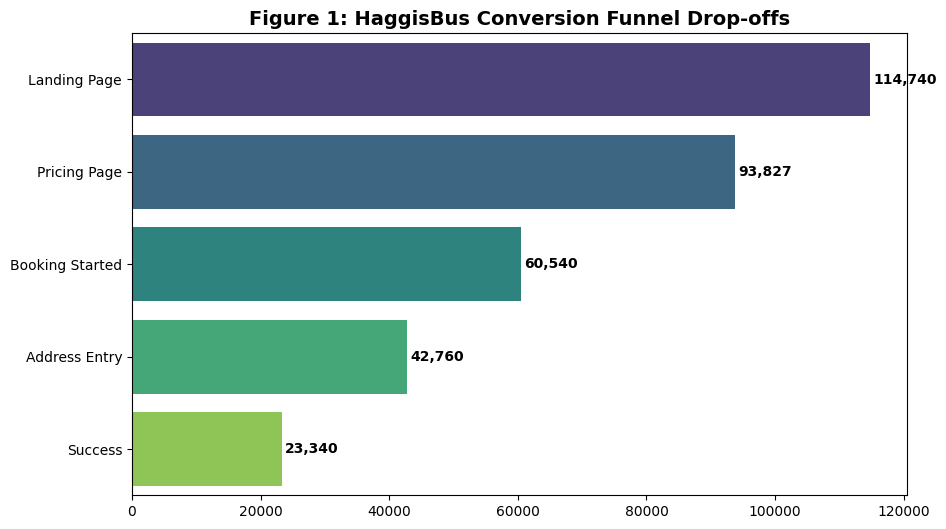

In [ ]:
# 1. Funnel Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=funnel_labels, palette='viridis')
for i, v in enumerate(counts):
    plt.text(v + 500, i, f'{int(v):,}', va='center', fontweight='bold')
plt.title('Figure 1: HaggisBus Conversion Funnel Drop-offs', fontsize=14, fontweight='bold')
plt.show()



**Figure 2 - Content Impact (Blogs)**

**Analysis**: We compared the conversion performance of users based on the blog content they consumed.

**Results**: *Blog 2* (Inspirational) leads to higher success rates than *Blog 1* (Instructional).

**Business Impact**: Creative storytelling is a more effective sales catalyst than technical instructions. We should prioritize the "*Blog 2*" style for future campaigns.

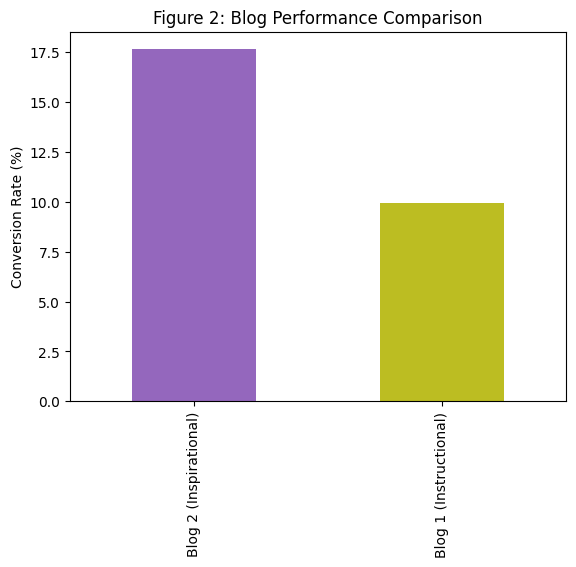

In [ ]:
# 2. Content Impact Analysis (Blogs)
df['visited_blog_1'] = df[page_cols].apply(lambda r: has_page(r, 'blog_1'), axis=1)
df['visited_blog_2'] = df[page_cols].apply(lambda r: has_page(r, 'blog_2'), axis=1)

blog_impact = {
    'Blog 2 (Inspirational)': df[df['visited_blog_2']]['Converted'].mean() * 100,
    'Blog 1 (Instructional)': df[df['visited_blog_1']]['Converted'].mean() * 100
}
pd.Series(blog_impact).plot(kind='bar', color=['#9467bd', '#bcbd22'])
plt.title('Figure 2: Blog Performance Comparison')
plt.ylabel('Conversion Rate (%)')
plt.show()


**Figure 3 - Marketing ROI**

**Analysis**: We compared the percentage of successful conversions against "Bounces" (immediate exits) per source.

**Results**: LinkedIn and Direct traffic are highly efficient. Facebook Adverts exhibit the highest waste with a 42.6% bounce rate.

**Business Impact**: High bounce rates on Facebook suggest poor ad targeting. Budget should be reallocated to LinkedIn to improve the quality of traffic.

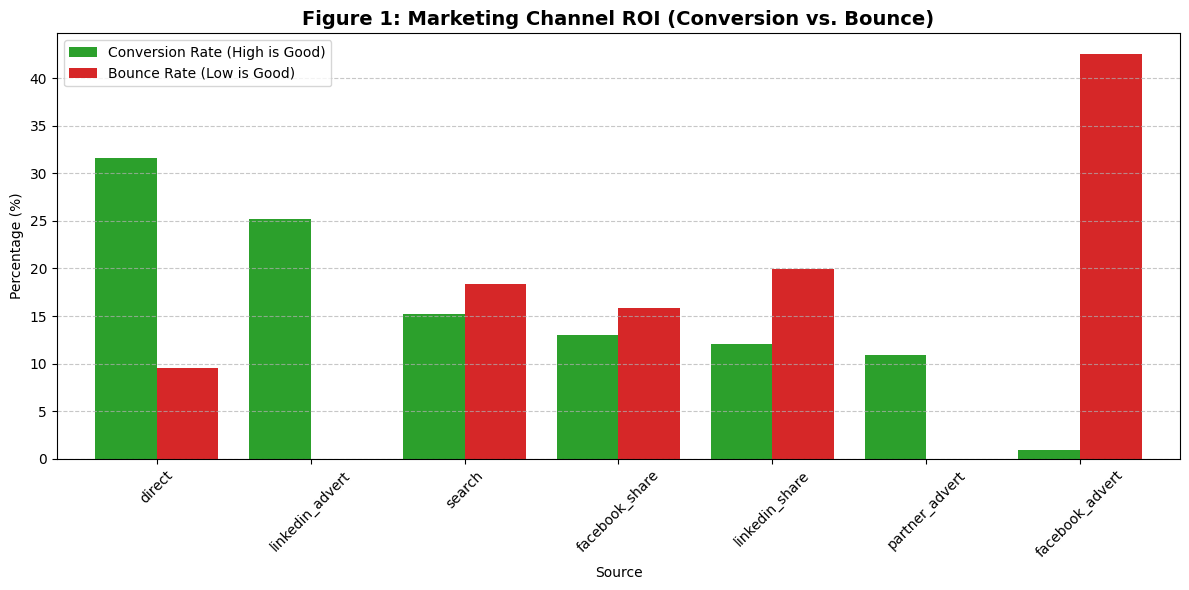

In [ ]:
# 3. Marketing ROI (Success vs. Bounce)
plt.figure(figsize=(12, 6))
plot_data = source_metrics[['Conv_Rate', 'Bounce_Rate']] * 100
plot_data.plot(kind='bar', color=['#2ca02c', '#d62728'], ax=plt.gca(), width=0.8)
plt.title('Figure 1: Marketing Channel ROI (Conversion vs. Bounce)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.legend(['Conversion Rate (High is Good)', 'Bounce Rate (Low is Good)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Figure 4 - Platform Performance**

**Analysis**: We audited the website’s effectiveness across different device types.

**Results**: Desktop platforms outperform mobile, with iOS (12.7%) sitting significantly below the site average.

**Business Impact**: This "*Mobile Gap*" confirms the need for a UI audit on mobile devices to ensure a smoother booking experience for iPhone users.

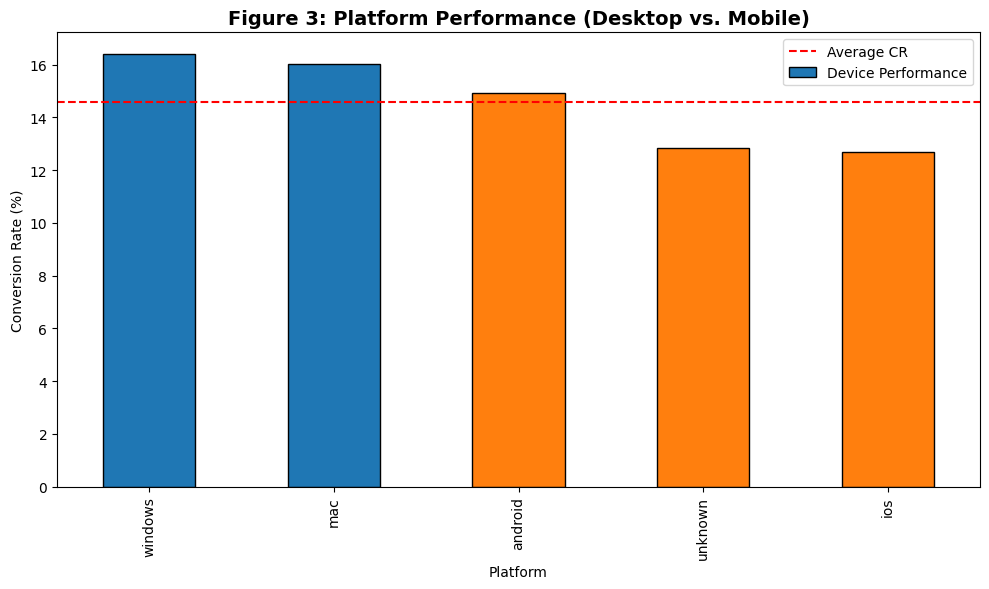

In [ ]:
# 4. Platform Performance (Desktop vs. Mobile)
plt.figure(figsize=(10, 6))
plat_plot_data = platform_metrics['Conv_Rate'] * 100
colors = ['#1f77b4' if x in ['windows', 'mac'] else '#ff7f0e' for x in plat_plot_data.index]
plat_plot_data.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Figure 3: Platform Performance (Desktop vs. Mobile)', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.axhline(plat_plot_data.mean(), color='red', linestyle='--', label='Average')
plt.legend(['Average CR', 'Device Performance'])
plt.tight_layout()
plt.show()